# Ejemplo Básico del Cálculo de Fallas con Zbus

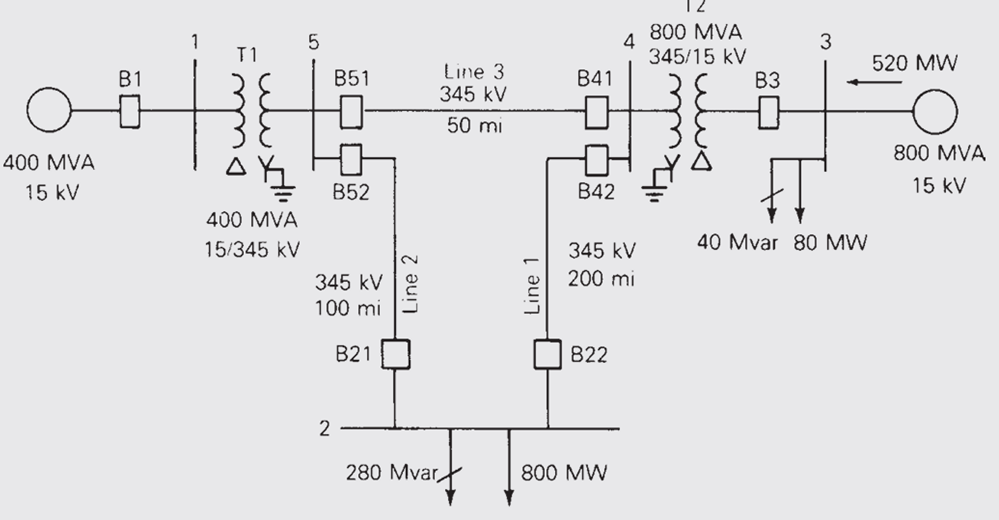

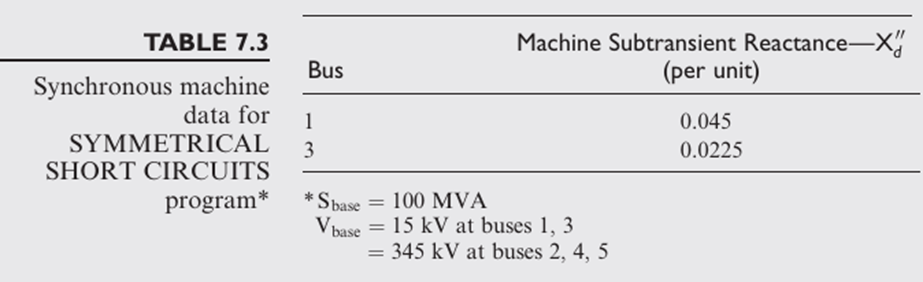

In [8]:
import numpy as np
import pandas as pd

# Número de nodos
n=5

# Crear un dataframe para los datos de las ramas
data = {
    "Bus_from": [2, 2, 4, 1, 3],
    "Bus_to": [4, 5, 5, 5, 4],
    "R_pu": [0, 0, 0, 0, 0],
    "X_pu": [0.100, 0.05, 0.025, 0.02, 0.01],
    "G_pu": [0, 0, 0, 0, 0],
    "B_pu": [0, 0, 0, 0, 0],
    #"B_pu": [1.72, 0.88, 0.44, 0, 0],
    "Tap": [None, None, None, None, None]
}
ramas = pd.DataFrame(data)
print(ramas)

# Crear un dataframe para los datos de los generadores
data= {
   "Bus":[1,3],
   "R_pu": [0, 0],
   "X_pu": [0.045, 0.0225],
}
gen=pd.DataFrame(data)
print(gen)

   Bus_from  Bus_to  R_pu   X_pu  G_pu  B_pu   Tap
0         2       4     0  0.100     0     0  None
1         2       5     0  0.050     0     0  None
2         4       5     0  0.025     0     0  None
3         1       5     0  0.020     0     0  None
4         3       4     0  0.010     0     0  None
   Bus  R_pu    X_pu
0    1     0  0.0450
1    3     0  0.0225


In [9]:
# Método básico para construir Ybus

def build_ybus(ramas,generadores, nbuses):
    Ybus = np.zeros((nbuses, nbuses), dtype=complex)

    for i in range(len(ramas)):
        k = int(ramas[i,0])-1  # Nodo "from" convertido a índice 0-based
        m = int(ramas[i,1])-1  # Nodo "to" convertido a índice 0-based

        R = ramas[i,2]  # extraer la resistencia en serie
        X = ramas[i,3]  # extraer la reactancia en serie
        G = ramas[i,4]  # extraer la conductancia
        B = ramas[i,5]  # extraer la susceptancia

        y_serie = 1/complex(R, X)  # Admitancia en serie
        y_shunt = complex(G,B)/2    # Susceptancia shunt por línea

        # Elementos de la diagonal
        Ybus[k,k]+=y_serie + y_shunt
        Ybus[m,m]+=y_serie + y_shunt

        # Elementos fuera de diagonal
        Ybus[k,m]-=y_serie
        Ybus[m,k]-=y_serie

    for i in range(len(generadores)):
        k = int(generadores[i,0])-1  # Nodo del generador
        Rg = generadores[i,1]  # extraer la resistencia en serie
        Xg = generadores[i,2]  # extraer la reactancia en serie

        yg_serie = 1/complex(Rg, Xg)  # Admitancia en serie
        # Elementos de la diagonal
        Ybus[k,k]+=yg_serie

    return Ybus

# Aplicación del método
Ybus=build_ybus(ramas.values,gen.values, n)

# Configurar opciones de impresión para mejor visualización de matrices
np.set_printoptions(precision=4, suppress=True, linewidth=100)
print(Ybus)

[[0. -72.2222j 0.  +0.j     0.  +0.j     0.  +0.j     0. +50.j    ]
 [0.  +0.j     0. -30.j     0.  +0.j     0. +10.j     0. +20.j    ]
 [0.  +0.j     0.  +0.j     0.-144.4444j 0.+100.j     0.  +0.j    ]
 [0.  +0.j     0. +10.j     0.+100.j     0.-150.j     0. +40.j    ]
 [0. +50.j     0. +20.j     0.  +0.j     0. +40.j     0.-110.j    ]]


#Cálculo de Zbus

In [23]:
Zbus = np.linalg.inv(Ybus)
print(Zbus)

[[0.+0.028j  0.+0.0177j 0.+0.0085j 0.+0.0123j 0.+0.0204j]
 [0.+0.0177j 0.+0.057j  0.+0.0136j 0.+0.0197j 0.+0.0256j]
 [0.+0.0085j 0.+0.0136j 0.+0.0182j 0.+0.0164j 0.+0.0123j]
 [0.+0.0123j 0.+0.0197j 0.+0.0164j 0.+0.0236j 0.+0.0178j]
 [0.+0.0204j 0.+0.0256j 0.+0.0123j 0.+0.0178j 0.+0.0295j]]


## Cálculo de las corrientes de falla

In [21]:
import cmath

# Definir función para corrientes de falla en un nodo

def falla(Zbus,Vf,nodo,Zf):
  If=Vf/(Zbus[nodo-1,nodo-1]+Zf)
  return If

# Aplicar la función para calcular todas las corrientes de fallas

Ifallas = np.zeros(n, dtype=complex)
for i in range(n):
  Ifallas[i]=falla(Zbus,1.05,i+1,0)
  print(Ifallas[i])

-37.53623188405799j
-18.436593725283423j
-57.55555555555559j
-44.45645263827084j
-35.62404482934286j


## Calcular tensiones de falla

In [26]:
# Generalizar el cálculo de las tensiones de falla para cada nodo
Vf_all = np.zeros((n, n), dtype=complex) # Para almacenar n vectores de tensión, cada uno de tamaño n

# Tensiones pre-falla
Vf_pre_fault = 1.05 * np.ones(n, dtype=complex)

for k in range(n): # k es el nodo fallado (0-indexado)
    # Calcular las tensiones de falla para todos los nodos cuando ocurre una falla en el nodo k
    Vf_all[k, :] = Vf_pre_fault - Zbus[k, :] * Ifallas[k]

print("Tensiones de falla para cada nodo (filas = nodo de falla, columnas = tensiones en cada nodo):")
print(Vf_all)

Tensiones de falla para cada nodo (filas = nodo de falla, columnas = tensiones en cada nodo):
[[0.    +0.j 0.3855+0.j 0.7304+0.j 0.5884+0.j 0.2841+0.j]
 [0.7236+0.j 0.    +0.j 0.7984+0.j 0.6865+0.j 0.5786+0.j]
 [0.56  +0.j 0.2644+0.j 0.    +0.j 0.1089+0.j 0.3422+0.j]
 [0.5033+0.j 0.1736+0.j 0.3231+0.j 0.    +0.j 0.2603+0.j]
 [0.3231+0.j 0.1391+0.j 0.6119+0.j 0.4172+0.j 0.    +0.j]]
